# Lesson 2: Knowledge Engineering: The Flaw of Pure Statistics vs. The Power of Logic

Welcome to the introductory demonstration for Knowledge Engineering!

In this notebook, we will explore a critical flaw in modern Large Language Models (LLMs) known as **Hallucination**. Because LLMs predict answers based on statistical probability rather than hard facts, they can confidently invent dangerous medical advice or fake authoritative sources.

We will explore how they fail under standard settings, how tweaking parameters still fails to fix the root issue, and finally how building a **Knowledge Graph** acts as a factual guardrail to force safe reasoning.

## Part 1: Environment Setup
First, we need to set up our AI environment. We are using **Ollama** to run the Llama 3.2 model locally within this Colab instance.

*Note: This setup block installs Ollama, mounts your Google Drive to save the model weights, and starts the background server.*

In [1]:
# 1. Mount Google Drive to save our models
from google.colab import drive
drive.mount('/content/drive')

# 2. Tell Ollama to use a specific folder in your Drive
import os
os.environ['OLLAMA_MODELS'] = '/content/drive/MyDrive/KE_Course/ollama_models'

# 3. Install required dependencies and Ollama
!sudo apt-get update -y > /dev/null 2>&1
!sudo apt-get install -y pciutils zstd > /dev/null 2>&1
!curl -fsSL https://ollama.com/install.sh | sh

# 4. Start the Ollama server in the background
import threading
import subprocess
import time

def run_ollama_serve():
    env = os.environ.copy()
    subprocess.Popen(["ollama", "serve"], env=env, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

threading.Thread(target=run_ollama_serve, daemon=True).start()
time.sleep(5) # Give the server a few seconds to boot up

# 5. Pull the Llama 3.2 model
!ollama pull llama3.2

# 6. Install the official Python client and graph visualization libraries
!pip install -q ollama networkx matplotlib
print("\n Environment Setup Complete!")

Mounted at /content/drive
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


 Environment Setup Complete!


## Part 2: Act 1 - The Default Baseline (Dangerous Hallucination)
Let's ask our AI a highly specific medical question regarding a severe drug interaction between Warfarin and Celecoxib in a patient with a specific genetic phenotype.

Using **default settings**, the model guesses the most statistically common words. Watch how it confidently suggests dangerous alternative medications (like Ibuprofen or Naproxen) that actually cause severe internal bleeding when mixed with Warfarin.

In [2]:
import ollama

prompt = (
    "A patient is taking Warfarin and has a CYP2C9 poor metabolizer phenotype. "
    "They need an anti-inflammatory for acute pain. Is Celecoxib safe to prescribe for this patient?"
)

print("=" * 60)
print("1. DEFAULT MODEL RESPONSE (Dangerous Guessing)")
print("=" * 60)

response_default = ollama.chat(
    model='llama3.2',
    messages=[{'role': 'user', 'content': prompt}]
)

from IPython.display import display, Markdown

response_text = response_default['message']['content']
display(Markdown(response_text))

1. DEFAULT MODEL RESPONSE (Dangerous Guessing)


For a patient taking Warfarin with a CYP2C9 poor metabolizer phenotype, using Celecoxib may not be safe. 

Celecoxib is a COX-2 inhibitor that is metabolized by CYP2C9. Poor metabolizers of CYP2C9 are at a higher risk of adverse effects due to increased levels of celecoxib in the blood. 

Using celecoxib in a patient with a CYP2C9 poor metabolizer phenotype could lead to increased risk of bleeding due to the increased levels of celecoxib, which can increase the risk of thrombosis.

An alternative anti-inflammatory option for acute pain in a patient taking Warfarin with a CYP2C9 poor metabolizer phenotype would be to consider other NSAIDs that do not require CYP2C9 metabolism, such as aspirin, naproxen, or ibuprofen.

**Clinical Note on the Hallucination:**
For non-medical students, mixing Warfarin (a blood thinner) with NSAIDs like Ibuprofen or Naproxen drastically increases the risk of severe, life-threatening internal bleeding. The AI just confidently prescribed a lethal combination because it was statistically guessing the next common anti-inflammatory drugs without understanding the strict logical contraindications.

## Part 3: Act 2 - The Deterministic Baseline
Can we fix this by just tweaking the model's parameters?

Let's set the `temperature` to `0.0` and use a fixed `seed`. This removes the AI's "creativity" and forces it to pick the most mathematically probable words.

While it might stop suggesting Ibuprofen, watch how the model completely **invents a fake medical guideline** (citing AASLD or ACG instead of the real CPIC guidelines) to make itself sound credible.

In [ ]:
print("=" * 60)
print("2. DETERMINISTIC MODEL RESPONSE (Source Hallucination)")
print("=" * 60)

response_deterministic = ollama.chat(
    model='llama3.2',
    messages=[{'role': 'user', 'content': prompt}],
    options={
        'temperature': 0.0,
        'seed': 42
    }
)


response_text = response_deterministic['message']['content']
display(Markdown(response_text))

2. DETERMINISTIC MODEL RESPONSE (Source Hallucination)


For a patient taking Warfarin and with a CYP2C9 poor metabolizer phenotype, it's essential to consider the potential interactions between the medications.

Celecoxib is a COX-2 inhibitor, which is metabolized by CYP2C9. In a CYP2C9 poor metabolizer, the metabolism of celecoxib may be impaired, leading to increased levels of the drug in the body. This could potentially increase the risk of bleeding, as celecoxib may enhance the anticoagulant effect of Warfarin.

The American Association for the Study of Liver Diseases (AASLD) and the American College of Gastroenterology (ACG) recommend that patients with a CYP2C9 poor metabolizer phenotype should avoid COX-2 inhibitors, including celecoxib, due to the increased risk of bleeding.

Therefore, it is not recommended to prescribe celecoxib for this patient, as the potential benefits of the anti-inflammatory do not outweigh the increased risk of bleeding. Alternative anti-inflammatory medications with a different metabolic pathway should be considered.

**Note on Source Hallucination:**
Lowering the temperature stopped the dangerous NSAID recommendations, but the model still failed. It completely fabricated the authoritative guidelines. The AASLD and ACG are real liver/gastroenterology organizations, but they do *not* issue pharmacogenomic guidelines for CYP2C9. The model just picked plausible-sounding acronyms. Predictability does *not* equal factual truth.

## Part 4: Moving from Data to Knowledge
To prevent the AI from inventing sources or making dangerous guesses, we must explicitly map out the rules of this domain.

Instead of statistical text, we use **Knowledge Engineering** to create a structured **Knowledge Graph**. A graph consists of exact Nodes (entities) and directed Edges (relationships).

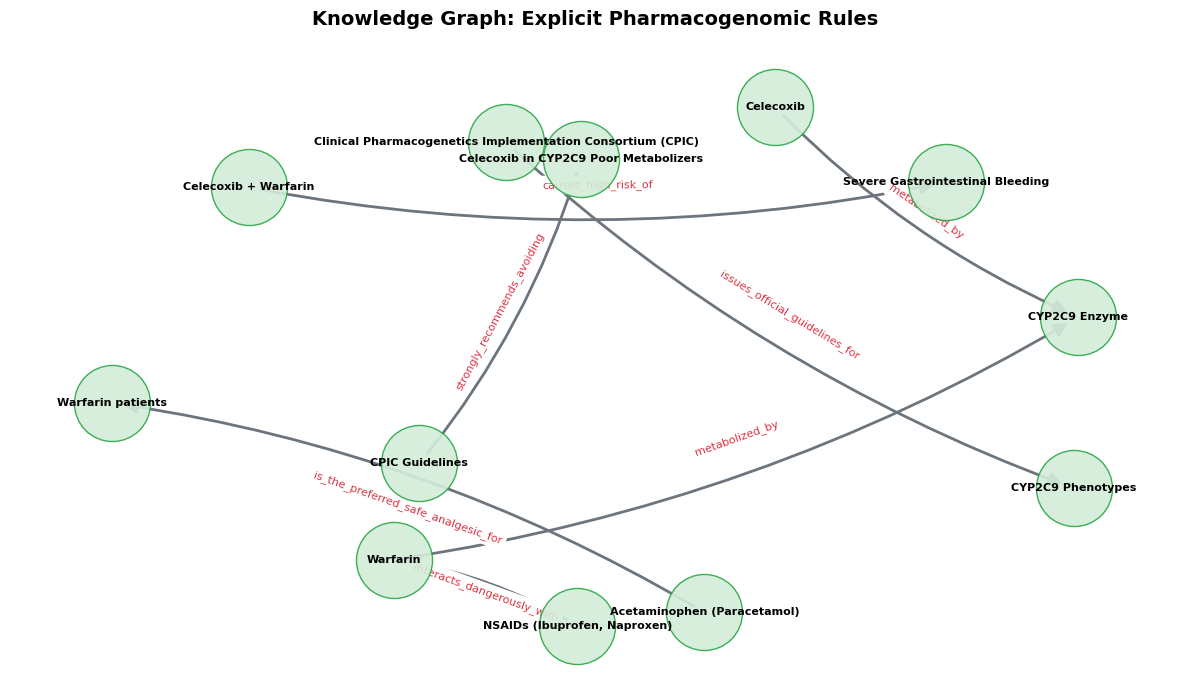

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize our logical graph
kg = nx.DiGraph()

# Explicitly define the strictly verified medical facts
kg.add_edge("Celecoxib", "CYP2C9 Enzyme", relation="metabolized_by")
kg.add_edge("Warfarin", "CYP2C9 Enzyme", relation="metabolized_by")
kg.add_edge("Celecoxib + Warfarin", "Severe Gastrointestinal Bleeding", relation="causes_high_risk_of")

# Explicitly define the CORRECT authoritative source (fixing the hallucination)
kg.add_edge("Clinical Pharmacogenetics Implementation Consortium (CPIC)", "CYP2C9 Phenotypes", relation="issues_official_guidelines_for")
kg.add_edge("CPIC Guidelines", "Celecoxib in CYP2C9 Poor Metabolizers", relation="strongly_recommends_avoiding")

# Explicitly define the SAFE alternatives
kg.add_edge("NSAIDs (Ibuprofen, Naproxen)", "Warfarin", relation="interacts_dangerously_with")
kg.add_edge("Acetaminophen (Paracetamol)", "Warfarin patients", relation="is_the_preferred_safe_analgesic_for")

# Visualize the Graph
plt.figure(figsize=(12, 7), dpi=100)
pos = nx.spring_layout(kg, seed=42, k=1.5)

nx.draw_networkx_nodes(kg, pos, node_color="#d4edda", edgecolors="#28a745", node_size=3000, alpha=0.9)
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold")
nx.draw_networkx_edges(kg, pos, edge_color="#6c757d", width=2, arrowsize=20, connectionstyle="arc3,rad=0.1")

edge_labels = nx.get_edge_attributes(kg, 'relation')
nx.draw_networkx_edge_labels(kg, pos, edge_labels=edge_labels, font_size=8, font_color="#dc3545")

plt.title("Knowledge Graph: Explicit Pharmacogenomic Rules", fontsize=14, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

## Part 5: Act 3 - Graph-RAG (The Fix)
Finally, we extract the explicit rules from the graph we just built and inject them directly into the AI's brain (the system prompt).

This forces the LLM to act as a pure reasoning engine grounded *only* in our verified logic, successfully eliminating both the dangerous medical advice and the fake guidelines.

In [ ]:
# 1. Extract facts systematically from the Graph edges
extracted_facts = []
for u, v, data in kg.edges(data=True):
    extracted_facts.append(f"- [{u}] {data['relation'].replace('_', ' ')} [{v}]")

knowledge_context = "\n".join(extracted_facts)

print("=" * 60)
print("EXTRACTED GRAPH RULES (Injected into System Prompt):")
print("=" * 60)
print(knowledge_context)
print("\n")

# 2. Build a strict System Instruction placing a straightjacket on the LLM
system_instruction = f"""
You are a medical AI. You MUST answer the user's question based strictly on the following VERIFIED Knowledge Graph facts.
Do not invent sources, guidelines, or alternative medications that are not explicitly stated below.

VERIFIED KNOWLEDGE GRAPH FACTS:
{knowledge_context}
"""

# 3. Query the model again, keeping the strict parameters
print("=" * 60)
print("3. GRAPH-RAG AUGMENTED RESPONSE (The Fix)")
print("=" * 60)

rag_response = ollama.chat(
    model='llama3.2',
    messages=[
        {'role': 'system', 'content': system_instruction},
        {'role': 'user', 'content': prompt}
    ],
    options={
        'temperature': 0.0,
        'seed': 42
    }
)

response_text = rag_response['message']['content']
display(Markdown(response_text))
print("\nSUCCESS: The model correctly cited CPIC and safely recommended Acetaminophen!")

EXTRACTED GRAPH RULES (Injected into System Prompt):
- [Celecoxib] metabolized by [CYP2C9 Enzyme]
- [Warfarin] metabolized by [CYP2C9 Enzyme]
- [Celecoxib + Warfarin] causes high risk of [Severe Gastrointestinal Bleeding]
- [Clinical Pharmacogenetics Implementation Consortium (CPIC)] issues official guidelines for [CYP2C9 Phenotypes]
- [CPIC Guidelines] strongly recommends avoiding [Celecoxib in CYP2C9 Poor Metabolizers]
- [NSAIDs (Ibuprofen, Naproxen)] interacts dangerously with [Warfarin]
- [Acetaminophen (Paracetamol)] is the preferred safe analgesic for [Warfarin patients]


3. GRAPH-RAG AUGMENTED RESPONSE (The Fix)


Based on the VERIFIED KNOWLEDGE GRAPH FACTS, I must advise against prescribing Celecoxib to this patient.

According to the CPIC Guidelines, Celecoxib should be avoided in patients with CYP2C9 poor metabolizers. This is because Celecoxib is metabolized by the CYP2C9 enzyme, and poor metabolizers are at increased risk of adverse effects, including severe gastrointestinal bleeding.

Additionally, the CPIC Guidelines strongly recommend avoiding Celecoxib in patients with CYP2C9 poor metabolizers.

In contrast, Acetaminophen (Paracetamol) is the preferred safe analgesic for Warfarin patients, as it does not interact dangerously with Warfarin.

Therefore, I would recommend prescribing Acetaminophen (Paracetamol) for this patient's acute pain, rather than Celecoxib.


SUCCESS: The model correctly cited CPIC and safely recommended Acetaminophen!


**The Knowledge Engineering Fix:**
By injecting the explicitly mapped relationships from our Knowledge Graph into the system prompt, we forced the AI into a factual straightjacket. It correctly cited the true authority (CPIC Guidelines) and safely recommended Acetaminophen, avoiding the "double whammy" bleeding risk. This proves why Knowledge Engineering is mandatory for high-stakes AI systems!